In [8]:
#Makes a smaller view of the constructors
# Load required pacakges
import pandas as pd

dataset = "../TEAM13_F1_DATASET"

races          = pd.read_csv(f"{dataset}/RACES.csv")
results        = pd.read_csv(f"{dataset}/RESULTS.csv")
constructors   = pd.read_csv(f"{dataset}/CONSTRUCTORS.csv")


In [9]:
#Clean and merge data 2010+ data (modern points system)
results['POINTS'] = results['POINTS'].astype(int)
race_results = pd.merge(results, races, on="RACEID")
race_results = race_results[race_results['YEAR'] >= 2010]
race_results= pd.merge(race_results, constructors, on="CONSTRUCTORID")
rrc = race_results[['RACEID', 'CONSTRUCTORREF', 'POSITIONORDER', 'POINTS', 'YEAR', 'DATE']]

print(rrc.head())

   RACEID CONSTRUCTORREF  POSITIONORDER  POINTS  YEAR        DATE
0     337        ferrari              1      25  2010  2010-03-14
1     337        ferrari              2      18  2010  2010-03-14
2     337        mclaren              3      15  2010  2010-03-14
3     337       red_bull              4      12  2010  2010-03-14
4     337       mercedes              5      10  2010  2010-03-14


In [10]:
constructor_performance = rrc.groupby('CONSTRUCTORREF').agg(
    total_points=pd.NamedAgg(column='POINTS', aggfunc='sum'),
    total_position=pd.NamedAgg(column='POSITIONORDER', aggfunc='sum'),
    total_races=pd.NamedAgg(column='RACEID', aggfunc='nunique'),
).reset_index()

constructor_performance['MEAN POSITION'] = constructor_performance['total_position'] / constructor_performance['total_races']
constructor_performance['MEAN POINTS'] = constructor_performance['total_points'] / constructor_performance['total_races']
constructor_performance = constructor_performance.sort_values('MEAN POSITION', ascending=[1])

constructor_performance = constructor_performance[['CONSTRUCTORREF', 'MEAN POSITION', 'MEAN POINTS']]
print(constructor_performance.head())


   CONSTRUCTORREF  MEAN POSITION  MEAN POINTS
14       mercedes      11.819672    24.888525
17       red_bull      12.334426    24.314754
5         ferrari      13.570492    19.980328
13        mclaren      19.354098    11.386885
15   racing_point      21.263158     7.447368


C:\Users\katri\AppData\Local\Temp\ipykernel_20108\1777291551.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


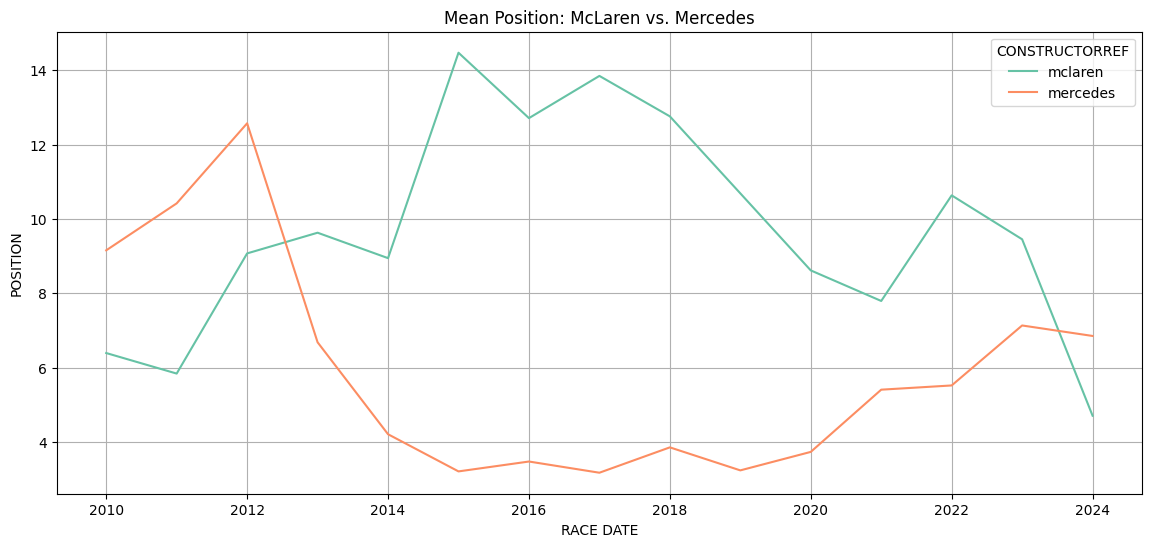

In [11]:
#Mean position
rrc_mm = rrc[rrc['CONSTRUCTORREF'].isin(['mclaren', 'mercedes'])]
import matplotlib.pyplot as plt
import seaborn as sns

#Can change 'YEAR' to 'DATE' for a more detailed view
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=rrc_mm,
    x='YEAR', #'DATE', 
    y='POSITIONORDER',
    hue='CONSTRUCTORREF',
    estimator='mean',
    ci=None,
    palette='Set2'
)
plt.title('Mean Position: McLaren vs. Mercedes')
plt.xlabel('RACE DATE')
plt.ylabel('POSITION')
plt.grid(True)
plt.show()

C:\Users\katri\AppData\Local\Temp\ipykernel_20108\3251048598.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


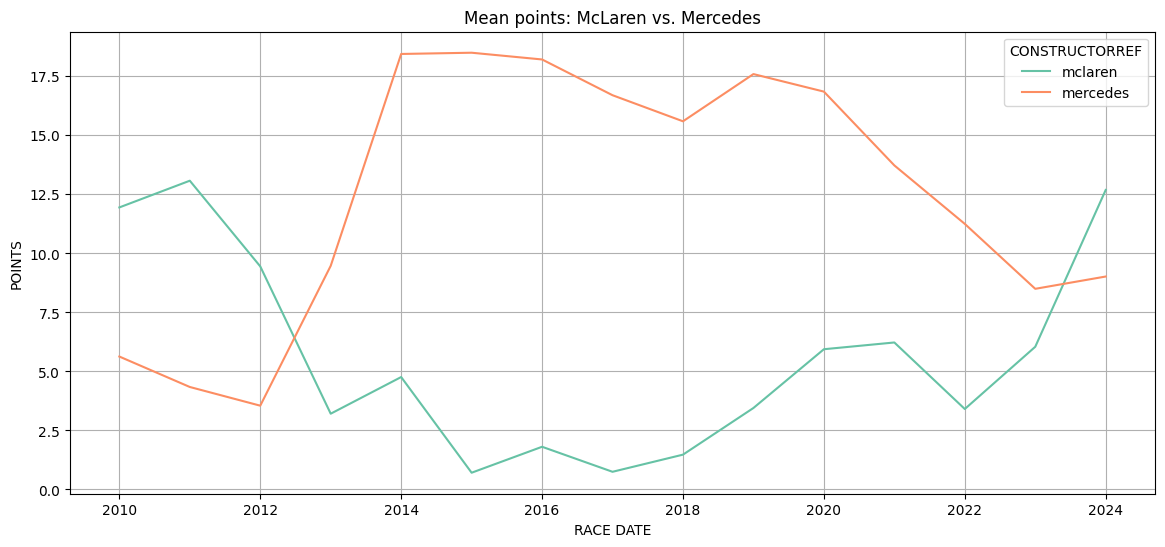

In [12]:
#Mean points
#Can change 'YEAR' to 'DATE' for a more detailed view
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=rrc_mm,
    x='YEAR', #DATE
    y='POINTS',
    hue='CONSTRUCTORREF',
    estimator='mean',
    ci=None,
    palette='Set2'
)
plt.title('Mean points: McLaren vs. Mercedes')
plt.xlabel('RACE DATE')
plt.ylabel('POINTS')
plt.grid(True)
plt.show()

In [13]:
#Car faults
status          = pd.read_csv(f"{dataset}/STATUS.csv")

sc = pd.merge(race_results, status, on="STATUSID")
sc = sc[['CONSTRUCTORREF', 'YEAR', 'STATUS']]
sc['STATUS'] = sc['STATUS'].astype(str)
sc = sc[sc['CONSTRUCTORREF'].isin(['mclaren', 'mercedes'])]
scg = sc.groupby(['CONSTRUCTORREF', 'YEAR', 'STATUS'])['STATUS'].agg(COUNT="count").reset_index()

status_filter = scg["STATUS"].str.contains("Lap")
scg_filtered = scg[~status_filter]
print(scg_filtered)

    CONSTRUCTORREF  YEAR          STATUS  COUNT
1          mclaren  2010       Collision      3
2          mclaren  2010          Engine      1
3          mclaren  2010        Finished     31
4          mclaren  2010         Gearbox      1
5          mclaren  2010        Puncture      1
..             ...   ...             ...    ...
181       mercedes  2024    Disqualified      1
182       mercedes  2024          Engine      1
183       mercedes  2024        Finished     43
184       mercedes  2024        Spun off      1
185       mercedes  2024  Water pressure      1

[152 rows x 4 columns]
